All columns in CSV:
['time', 'signal2_clean', 'signal2_noisy', 'signal3_clean', 'signal3_noisy', 'signal4_clean', 'signal4_noisy', 'global_temperature']

Input columns used:
['signal2_noisy', 'signal3_noisy', 'signal4_noisy', 'global_temperature']

Target column used:
['global_temperature']

First 5 rows of selected input signals:
   signal2_noisy  signal3_noisy  signal4_noisy  global_temperature
0       1.001286       1.682292      -0.723035            0.000000
1       1.616492       1.726360      -1.360997            0.157214
2       1.110718       1.712260      -1.290629            0.310518
3       2.273823       1.795313      -1.334019            0.456099
4       2.397601       2.263011      -0.937873            0.590337

Missing values in selected input signals:
signal2_noisy         61
signal3_noisy         46
signal4_noisy         39
global_temperature     0
dtype: int64


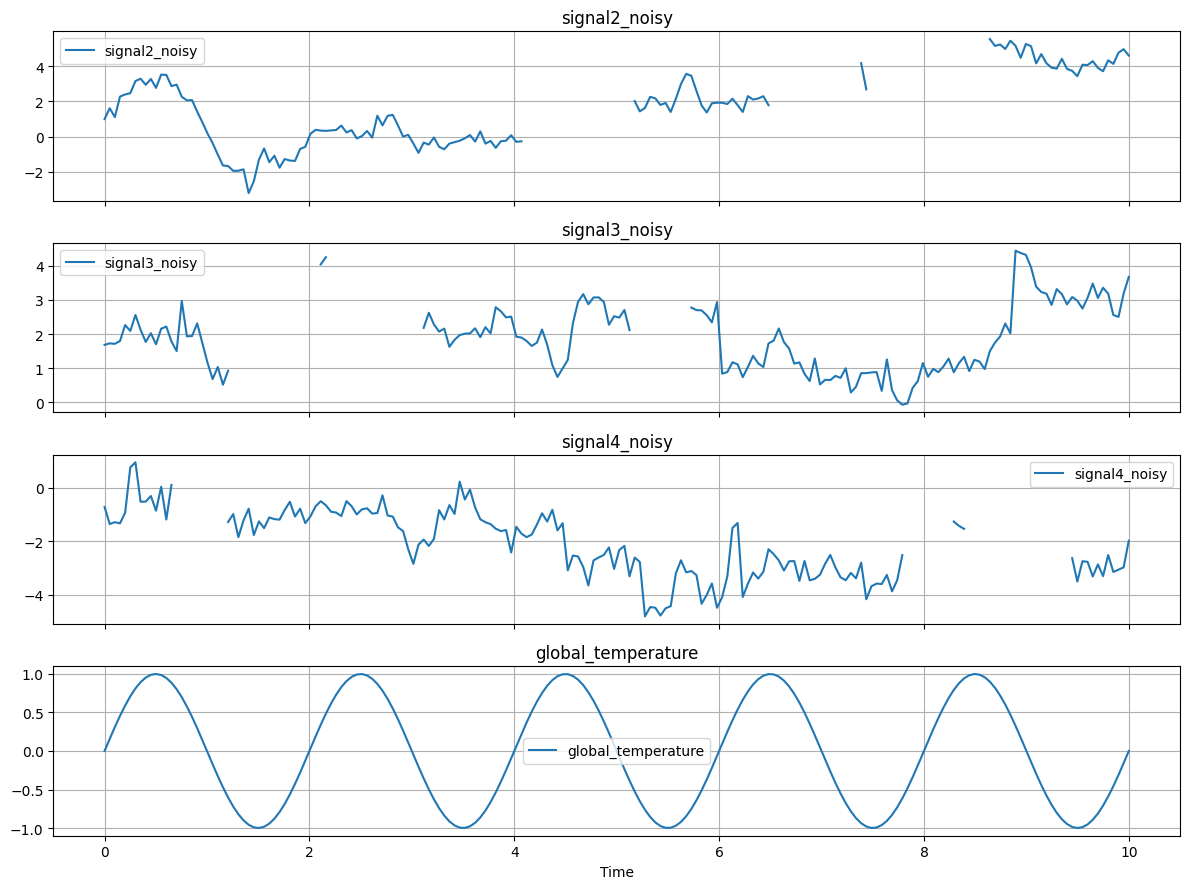


NaNs in X_norm: 0
NaNs in Y_norm: 0

X_raw shape: (200, 4)
mask shape: (200, 4)
X_model shape: (200, 8)
X_norm shape: (1, 200, 8)

Y_raw shape: (200, 1)
Y_norm shape: (1, 200, 1)

Each time point input contains:
['signal2_noisy', 'signal3_noisy', 'signal4_noisy', 'global_temperature', 'signal2_noisy_mask', 'signal3_noisy_mask', 'signal4_noisy_mask', 'global_temperature_mask']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load data

df = pd.read_csv("three_noisy_signals.csv")

# time
t = df["time"].values

# recreate true global temperature
df["global_temperature"] = np.sin(2 * np.pi * 0.5 * t)


# Choose input signals

input_columns = [
    "signal2_noisy",
    "signal3_noisy",
    "signal4_noisy",
    "global_temperature"
]

target_columns = [
    "global_temperature"
]


# Check columns

print("All columns in CSV:")
print(df.columns.tolist())

print("\nInput columns used:")
print(input_columns)

print("\nTarget column used:")
print(target_columns)

print("\nFirst 5 rows of selected input signals:")
print(df[input_columns].head())

print("\nMissing values in selected input signals:")
print(df[input_columns].isna().sum())


# Plot selected signals

fig, axs = plt.subplots(len(input_columns), 1, figsize=(12, 9), sharex=True)

for ax, col in zip(axs, input_columns):
    ax.plot(t, df[col], label=col)
    ax.set_title(col)
    ax.legend()
    ax.grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()


# Build input X

X_raw = df[input_columns].values

# mask: 1 = observed, 0 = missing
mask = (~np.isnan(X_raw)).astype(float)

# fill missing values with column means
col_means = np.nanmean(X_raw, axis=0)
X_filled = np.where(np.isnan(X_raw), col_means, X_raw)

# add mask channels
X_model = np.concatenate([X_filled, mask], axis=1)


# Build target Y

Y_raw = df[target_columns].values


# Reshape for sequence mode
X = X_model[np.newaxis, :, :]
Y = Y_raw[np.newaxis, :, :]


# Normalize input

X_mean = X.mean()
X_std = X.std() + 1e-8
X_norm = (X - X_mean) / X_std


# Normalize target

Y_mean = Y.mean()
Y_std = Y.std() + 1e-8
Y_norm = (Y - Y_mean) / Y_std


# Final checks

print("\nNaNs in X_norm:", np.isnan(X_norm).sum())
print("NaNs in Y_norm:", np.isnan(Y_norm).sum())

print("\nX_raw shape:", X_raw.shape)
print("mask shape:", mask.shape)
print("X_model shape:", X_model.shape)
print("X_norm shape:", X_norm.shape)

print("\nY_raw shape:", Y_raw.shape)
print("Y_norm shape:", Y_norm.shape)

print("\nEach time point input contains:")
print(input_columns + [col + "_mask" for col in input_columns])

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 1.0327
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.9851
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.9556
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.9281
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.8974
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.8651
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.8338
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.8047
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.7770
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.7490
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.7197
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.6894
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.6589
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.6290
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.5994
Epoch 16/200
1/1 

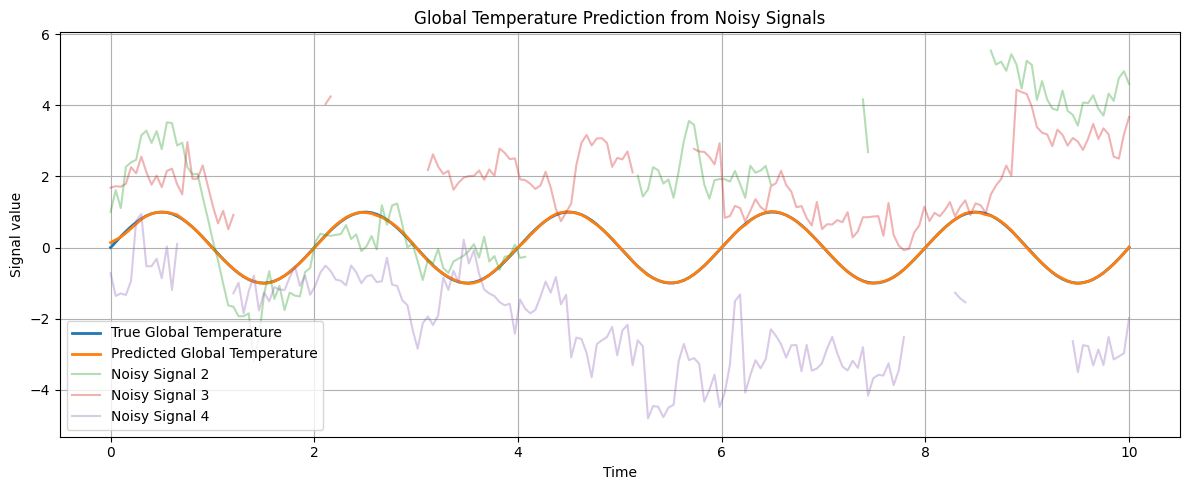

In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


# Model

inputs = Input(shape=(X_norm.shape[1], X_norm.shape[2]))

lstm_out = LSTM(64, return_sequences=True)(inputs)
attn_out = Attention()([lstm_out, lstm_out])

x = Concatenate()([lstm_out, attn_out])

# only 1 output: global_temperature
outputs = Dense(1)(x)

attention_model = Model(inputs, outputs)

attention_model.compile(optimizer="adam", loss="mse")

history = attention_model.fit(
    X_norm,
    Y_norm,
    epochs=200,
    batch_size=1,
    verbose=1
)


# Predict

Y_pred_norm = attention_model.predict(X_norm)

Y_pred = Y_pred_norm * Y_std + Y_mean
Y_true = Y_norm * Y_std + Y_mean


# Plot

plt.figure(figsize=(12, 5))

plt.plot(t, Y_true[0, :, 0], label="True Global Temperature", linewidth=2)
plt.plot(t, Y_pred[0, :, 0], label="Predicted Global Temperature", linewidth=2)

plt.plot(t, df["signal2_noisy"], alpha=0.35, label="Noisy Signal 2")
plt.plot(t, df["signal3_noisy"], alpha=0.35, label="Noisy Signal 3")
plt.plot(t, df["signal4_noisy"], alpha=0.35, label="Noisy Signal 4")

plt.title("Global Temperature Prediction from Noisy Signals")
plt.xlabel("Time")
plt.ylabel("Signal value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()